In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

'Bonafide Certificate_Summer Internship_2025_IIT Dharwad.docx'
 checkpoint.pth
 Classroom
'Colab Notebooks'
 Dataset
' datt'
 final_model.pth
'MyCV (1).pdf'
 MyCV_SACHIN_YADAV_.pdf
 SachinCV.pdf


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [ ]:
train_path = "/content/drive/MyDrive/Dataset/Training"
test_path  = "/content/drive/MyDrive/Dataset/Testing"

print(os.path.exists(train_path))  # must be True
print(os.path.exists(test_path))   # must be True

train_data = datasets.ImageFolder(train_path, transform=transform)
test_data  = datasets.ImageFolder(test_path, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

classes = train_data.classes
num_classes = len(classes)

print("Classes:", classes)

True
True
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
!ls /content/drive/MyDrive/Dataset

Testing  Training


In [ ]:
train_path = "/content/Dataset/Training"
test_path  = "/content/Dataset/Testing"

In [ ]:
# =========================
# 7. CNN MODEL
# =========================
class CNN_Model(nn.Module):
    def __init__(self, num_classes=4):
        super(CNN_Model, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(128 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

model = CNN_Model(num_classes).to(device)

In [ ]:
# =========================
# 8. Loss & Optimizer
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# =========================
# 9. SAVE PATH
# =========================
model_path = "/content/drive/MyDrive/cnn_model.pth"

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_Model(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 20
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/20], Loss: 0.7715
Epoch [2/20], Loss: 0.4321
Epoch [3/20], Loss: 0.3283
Epoch [4/20], Loss: 0.2463
Epoch [5/20], Loss: 0.1963
Epoch [6/20], Loss: 0.1397
Epoch [7/20], Loss: 0.1088
Epoch [8/20], Loss: 0.0964
Epoch [9/20], Loss: 0.0817
Epoch [10/20], Loss: 0.0458
Epoch [11/20], Loss: 0.0314
Epoch [12/20], Loss: 0.0388
Epoch [13/20], Loss: 0.0244
Epoch [14/20], Loss: 0.0388
Epoch [15/20], Loss: 0.0253
Epoch [16/20], Loss: 0.0213
Epoch [17/20], Loss: 0.0228
Epoch [18/20], Loss: 0.0293
Epoch [19/20], Loss: 0.0133
Epoch [20/20], Loss: 0.0222


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 89.38%


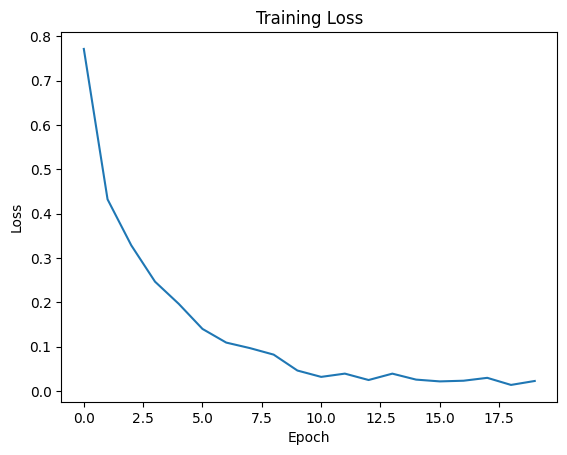

In [ ]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()